# Diabetes Classification — Feature Engineering Comparison

> Uses **not.ipynb's feature engineering** with the same model pipeline as the organized notebook.
> Compare results with `ML_DIABETES_PREDICTION_ORGANIZED.ipynb` to evaluate which feature engineering approach works better.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     StratifiedKFold, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, precision_recall_curve,
                             roc_auc_score, roc_curve, precision_score, recall_score)
from scipy.stats import uniform, randint

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Data Loading

In [3]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# Exploratory Data Analysis (EDA)

In [4]:
df.shape

(100000, 9)

In [5]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [7]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(96146, 9)

In [10]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [11]:
df.nunique()

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

In [12]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# **EDA**

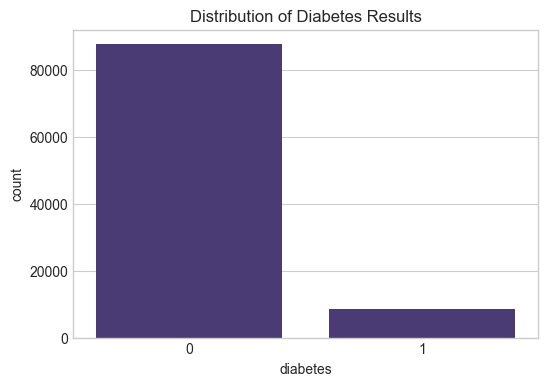

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribution of Diabetes Results')
plt.show()

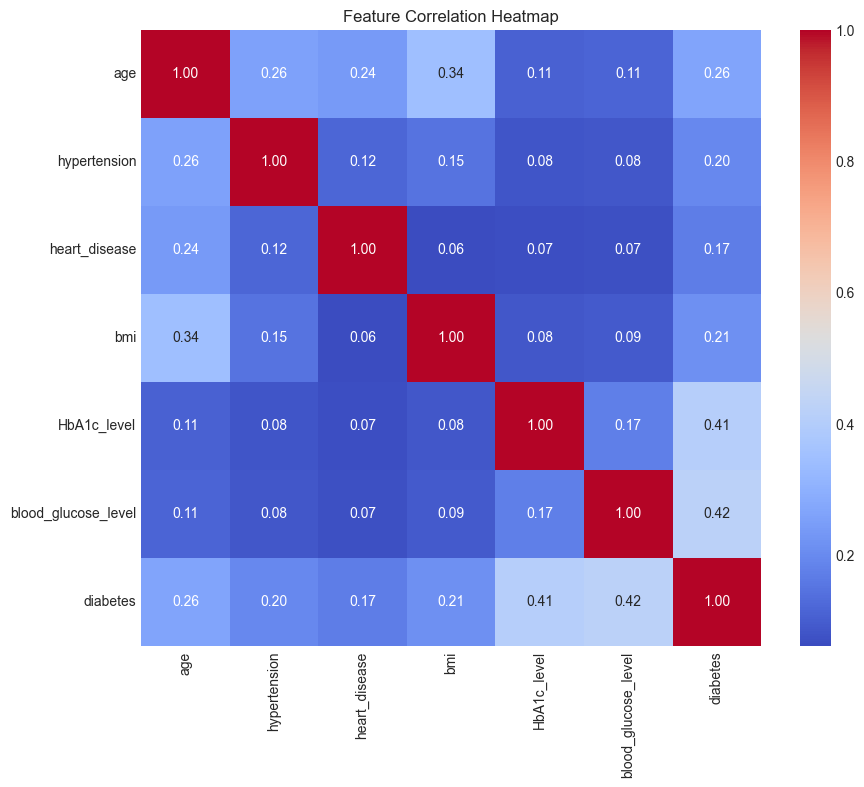

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

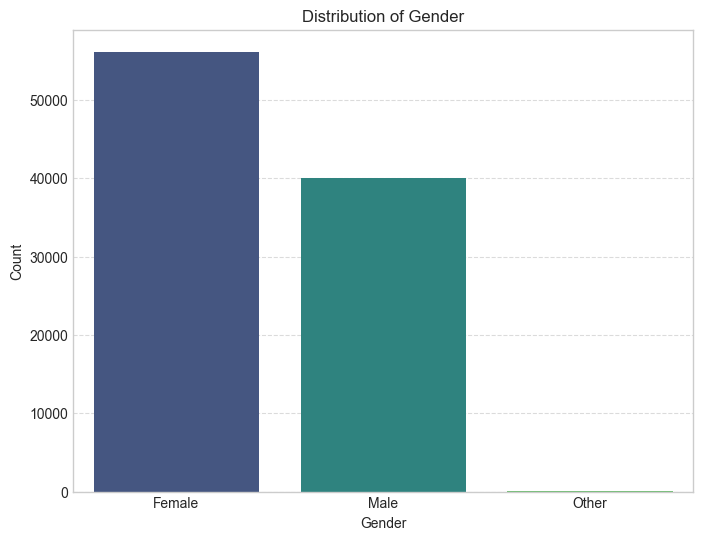

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

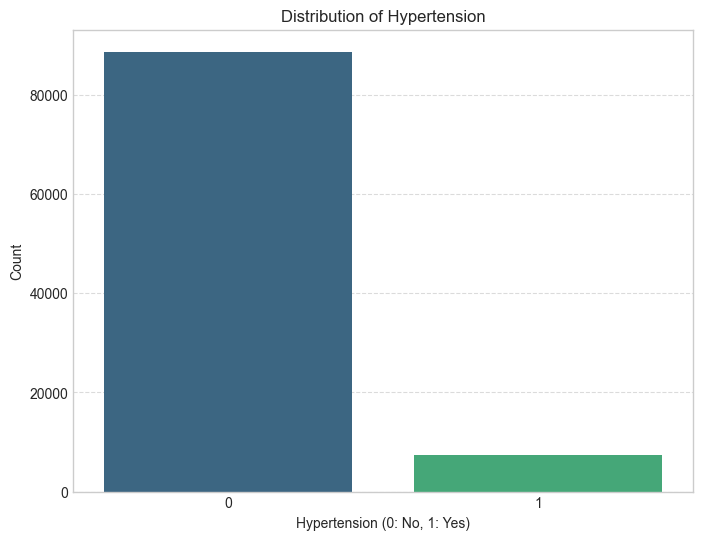

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(x='hypertension', hue='hypertension', data=df, palette='viridis', legend=False)
plt.title('Distribution of Hypertension')
plt.xlabel('Hypertension (0: No, 1: Yes)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

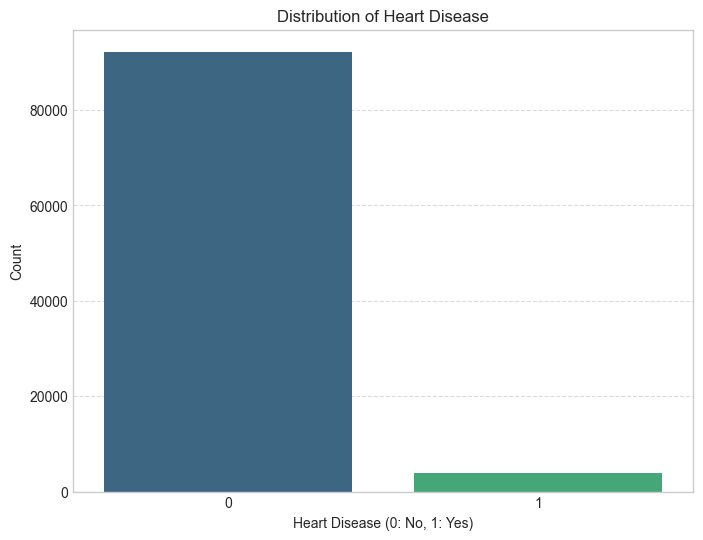

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(x='heart_disease', hue='heart_disease', data=df, palette='viridis', legend=False)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

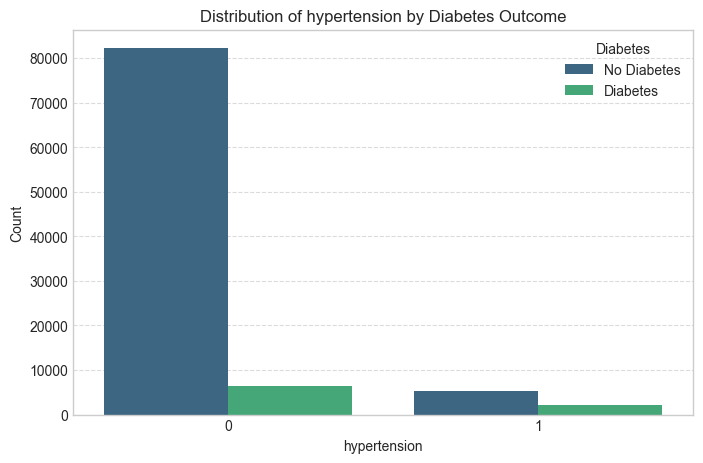

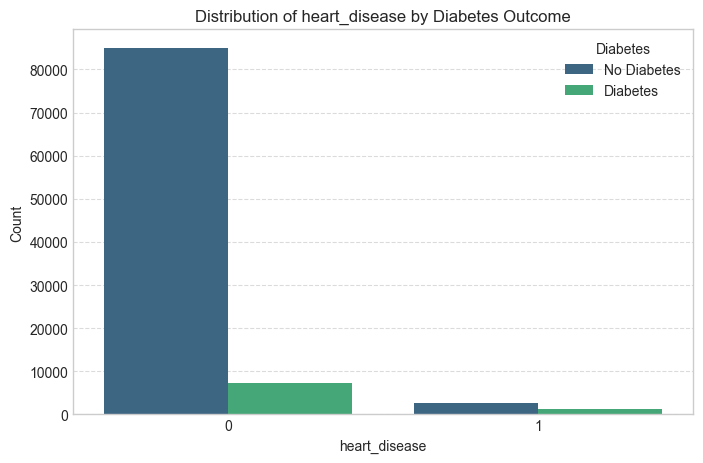

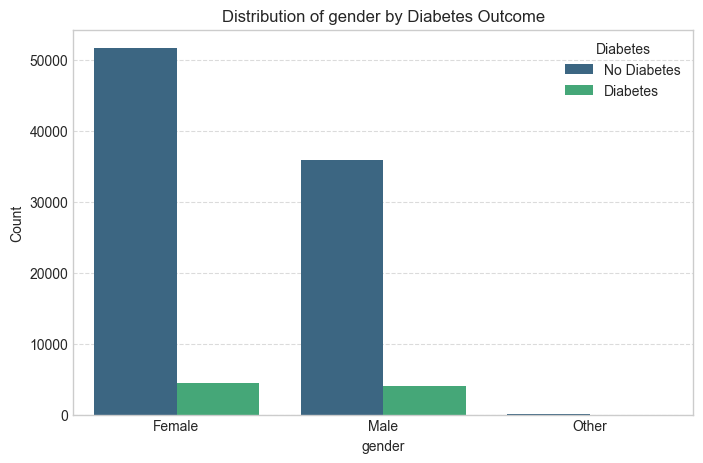

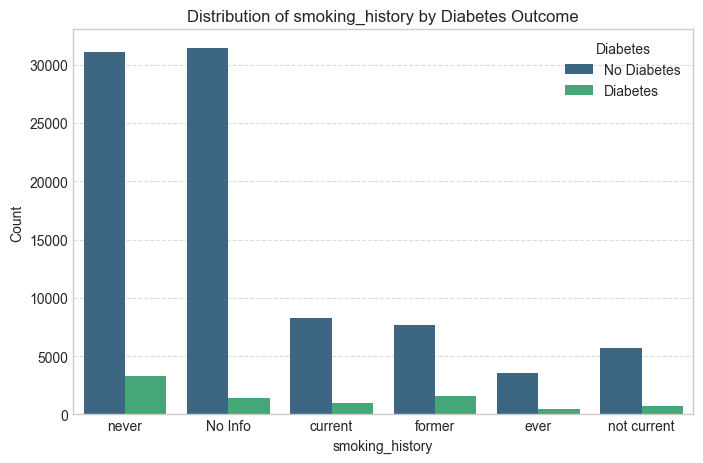

In [18]:
categorical_cols = [
    'hypertension', 'heart_disease', 'gender', 'smoking_history'
]

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='diabetes', data=df, palette='viridis')
    plt.title(f'Distribution of {col} by Diabetes Outcome')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Diabetes', labels=['No Diabetes', 'Diabetes'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

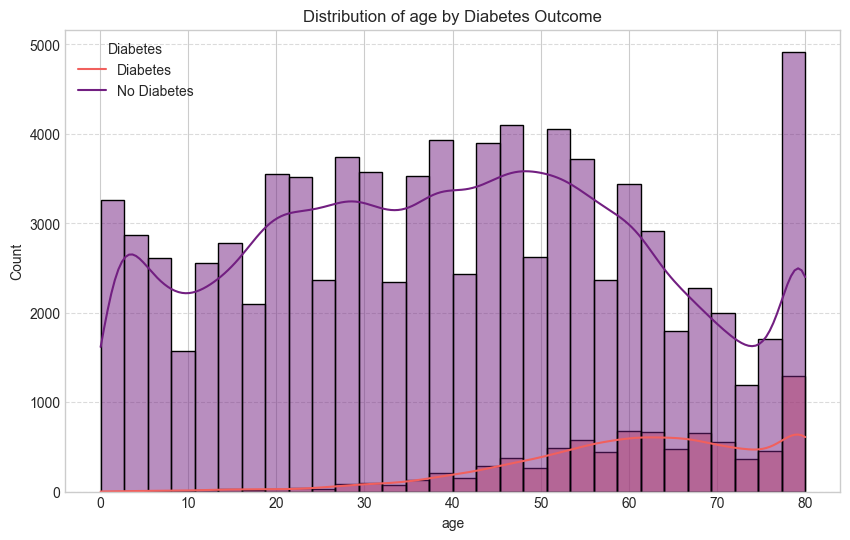

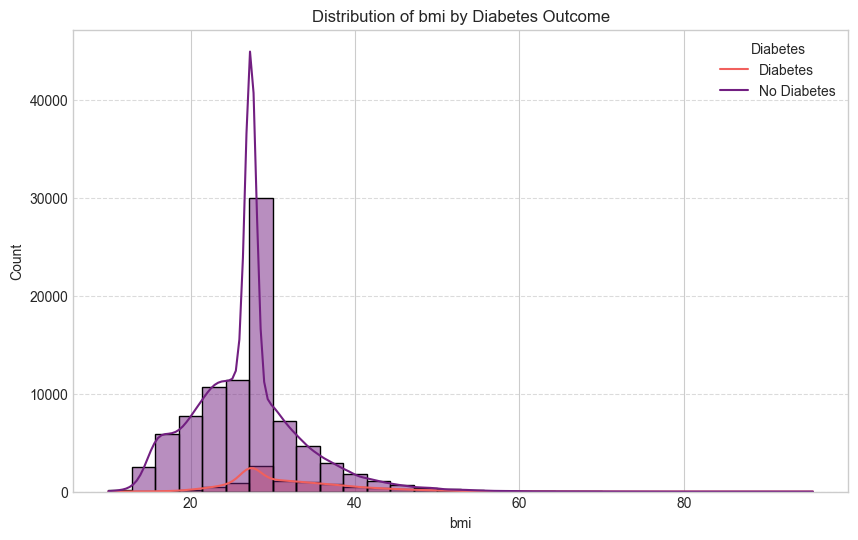

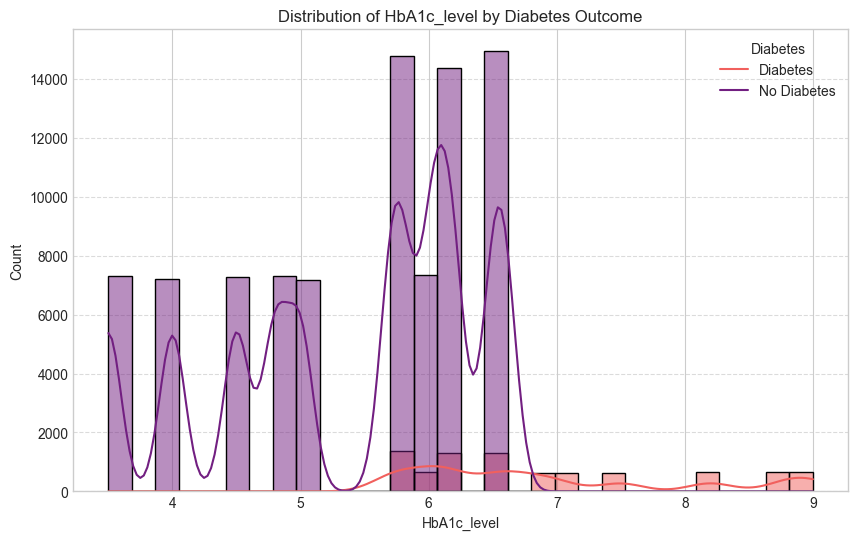

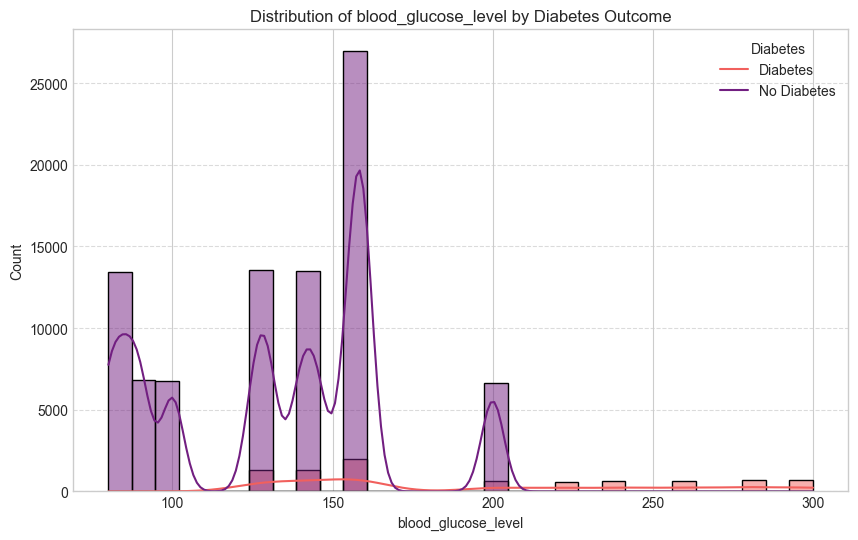

In [19]:
numerical_cols = [
    'age', 'bmi', 'HbA1c_level', 'blood_glucose_level'
]

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, hue='diabetes', kde=True, palette='magma', bins=30)
    plt.title(f'Distribution of {col} by Diabetes Outcome')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Diabetes', labels=['Diabetes', 'No Diabetes'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [20]:
df_scatter = df.copy()
df_scatter['diabetes_status'] = df_scatter['diabetes'].map({0: 'No Diabetes', 1: 'Diabetes'})

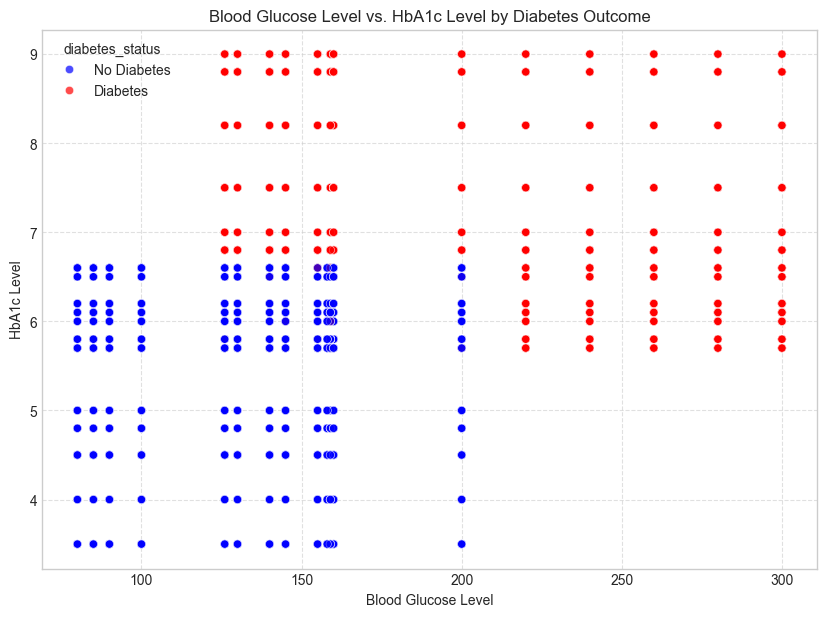

In [21]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='blood_glucose_level', y='HbA1c_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('Blood Glucose Level vs. HbA1c Level by Diabetes Outcome')
plt.xlabel('Blood Glucose Level')
plt.ylabel('HbA1c Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

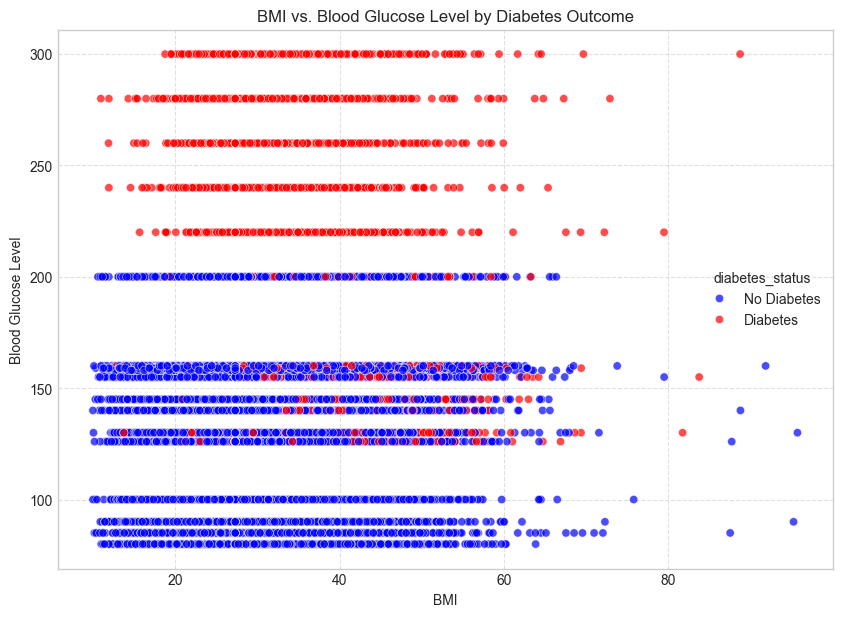

In [22]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='bmi', y='blood_glucose_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('BMI vs. Blood Glucose Level by Diabetes Outcome')
plt.xlabel('BMI')
plt.ylabel('Blood Glucose Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

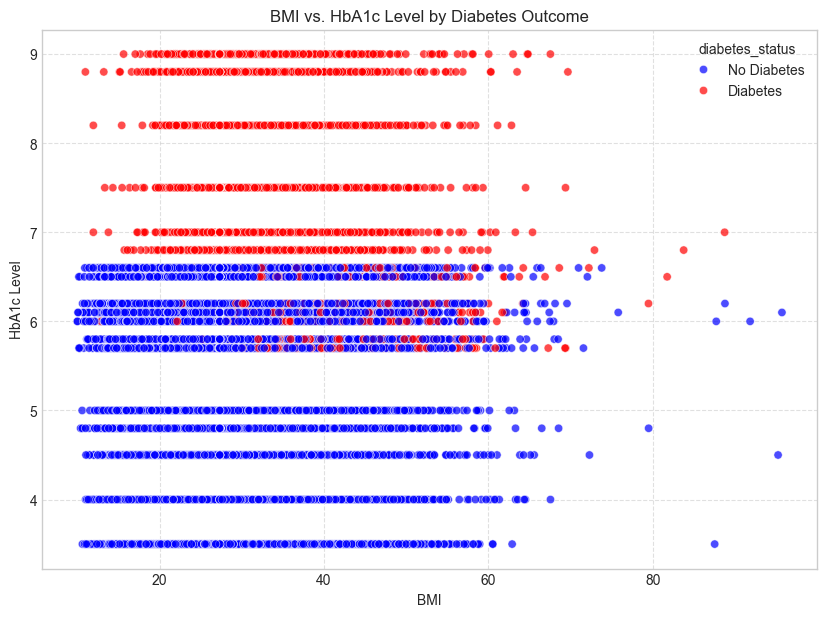

In [23]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='bmi', y='HbA1c_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('BMI vs. HbA1c Level by Diabetes Outcome')
plt.xlabel('BMI')
plt.ylabel('HbA1c Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

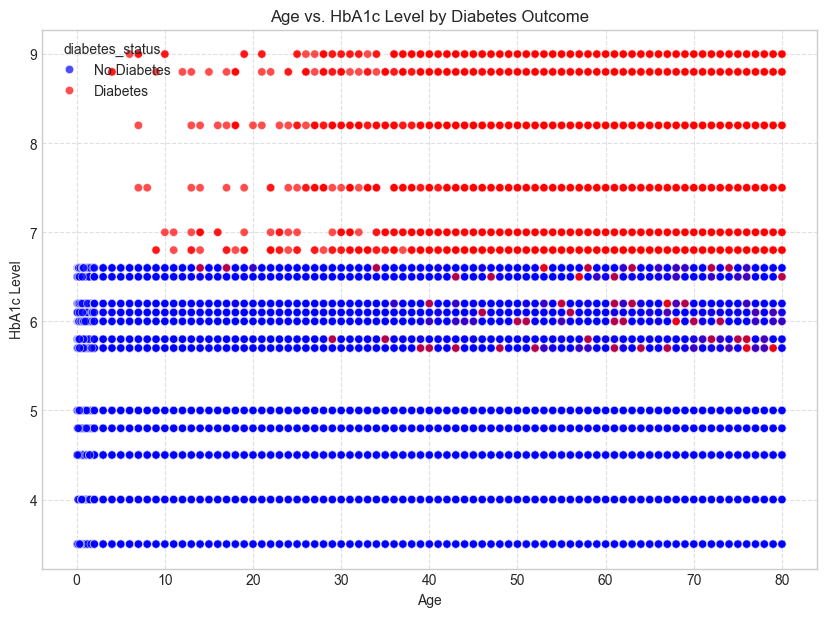

In [24]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='HbA1c_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('Age vs. HbA1c Level by Diabetes Outcome')
plt.xlabel('Age')
plt.ylabel('HbA1c Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

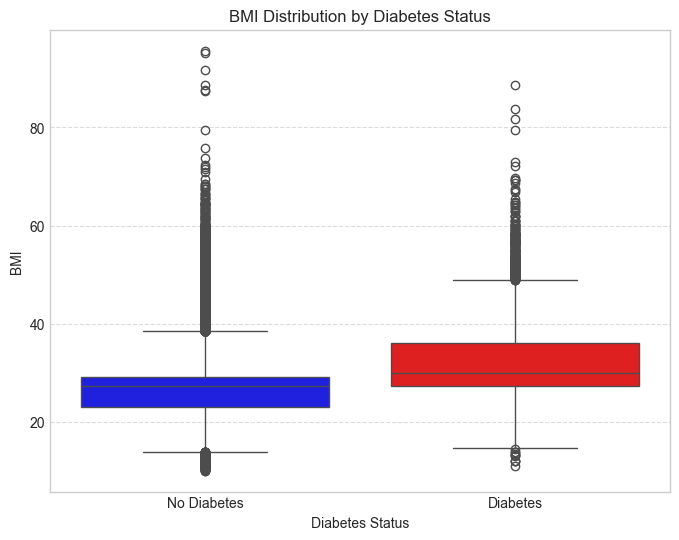

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diabetes_status', y='bmi', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, legend=False)
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('BMI')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Feature Engineering (from not.ipynb)

This uses the feature engineering approach from `not.ipynb`, which differs from the team's organized notebook.
Key differences:
- Smoking history → 3 categories (baseline, former, No_Info) instead of ordinal mapping
- `glucose_hba1c_interaction` — strongest engineered feature (0.57 correlation with target)
- `age_bmi_interaction` — captures age-weight risk interaction
- `bmi_is_default` flag — identifies suspected fill value (27.32)
- `high_risk_flag` — combined HbA1c ≥ 6.5 AND glucose ≥ 200

In [26]:
# Remove duplicates
print(f"Before removing duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"After removing duplicates: {df.shape}")

Before removing duplicates: (96146, 9)
After removing duplicates: (96146, 9)


In [27]:
# Smoking history consolidation: 6 categories → 3
print("Before:", df['smoking_history'].unique())

df['smoking_history'] = df['smoking_history'].replace({
    'former': 'former',
    'never': 'baseline',
    'current': 'baseline',
    'ever': 'baseline',
    'not current': 'baseline',
    'No Info': 'No_Info'
})

print("After:", df['smoking_history'].unique())

Before: ['never' 'No Info' 'current' 'former' 'ever' 'not current']
After: ['baseline' 'No_Info' 'former']


In [28]:
# Interaction features
df['glucose_hba1c_interaction'] = df['HbA1c_level'] * df['blood_glucose_level']
df['cardio_risk_index'] = df['hypertension'] + df['heart_disease']
df['age_bmi_interaction'] = df['age'] * df['bmi']
df['glucose_bmi_interaction'] = df['blood_glucose_level'] * df['bmi']

# Binned features
df['bmi_category'] = pd.cut(df['bmi'],
                bins=[-float('inf'), 18.5, 25, 30, float('inf')],
                labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

df['age_groups'] = pd.cut(df['age'],
                          bins=[-float('inf'), 18, 40, 60, float('inf')],
                          labels=['Child', 'Adult', 'Middle Age', 'Senior'])

# Flag features
df['bmi_is_default'] = (df['bmi'] == 27.32).astype(int)
df['high_risk_flag'] = ((df['HbA1c_level'] >= 6.5) & (df['blood_glucose_level'] >= 200)).astype(int)

print("Engineered features added:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")

Engineered features added:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'glucose_hba1c_interaction', 'cardio_risk_index', 'age_bmi_interaction', 'glucose_bmi_interaction', 'bmi_category', 'age_groups', 'bmi_is_default', 'high_risk_flag']

Shape: (96146, 17)


In [29]:
# Check correlation of engineered features with target
corr = df.corr(numeric_only=True)['diabetes'].sort_values(ascending=False)
print("Feature correlations with diabetes:")
print(corr)

Feature correlations with diabetes:
diabetes                     1.000000
glucose_hba1c_interaction    0.569883
glucose_bmi_interaction      0.466101
blood_glucose_level          0.424336
HbA1c_level                  0.406408
high_risk_flag               0.404690
age_bmi_interaction          0.321812
age                          0.264927
cardio_risk_index            0.245177
bmi                          0.214932
hypertension                 0.195710
heart_disease                0.170711
bmi_is_default              -0.034879
Name: diabetes, dtype: float64


In [30]:
# One-hot encode categoricals (gender, smoking_history, bmi_category, age_groups)
df = pd.get_dummies(df, columns=['gender', 'smoking_history', 'bmi_category', 'age_groups'], drop_first=True)
print(f"Shape after encoding: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape after encoding: (96146, 23)
Columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'glucose_hba1c_interaction', 'cardio_risk_index', 'age_bmi_interaction', 'glucose_bmi_interaction', 'bmi_is_default', 'high_risk_flag', 'gender_Male', 'gender_Other', 'smoking_history_baseline', 'smoking_history_former', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese', 'age_groups_Adult', 'age_groups_Middle Age', 'age_groups_Senior']


# Data Splitting & Preprocessing

- **80/20 stratified** train/test split
- **StratifiedKFold(5)** for cross-validation during hyperparameter search

In [31]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# CV strategy for hyperparameter tuning
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Class imbalance ratio: {imbalance_ratio:.1f}:1")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training set: 76916 samples
Test set: 19230 samples
Class imbalance ratio: 10.3:1

Training class distribution:
diabetes
0    70130
1     6786
Name: count, dtype: int64

Test class distribution:
diabetes
0    17534
1     1696
Name: count, dtype: int64


# PCA (Dimensionality Reduction)

PCA-transformed data available for models that benefit from it (e.g., MLP, SVM).  
Tree-based models (RF, GB) work directly on raw features.

Original features: 22
PCA components: 14
Explained variance ratio: [0.20838615 0.11558447 0.09829493 0.09183177 0.06766784 0.0629798
 0.06139276 0.04566583 0.04480646 0.04250893 0.03870359 0.03558981
 0.02775131 0.02474332]


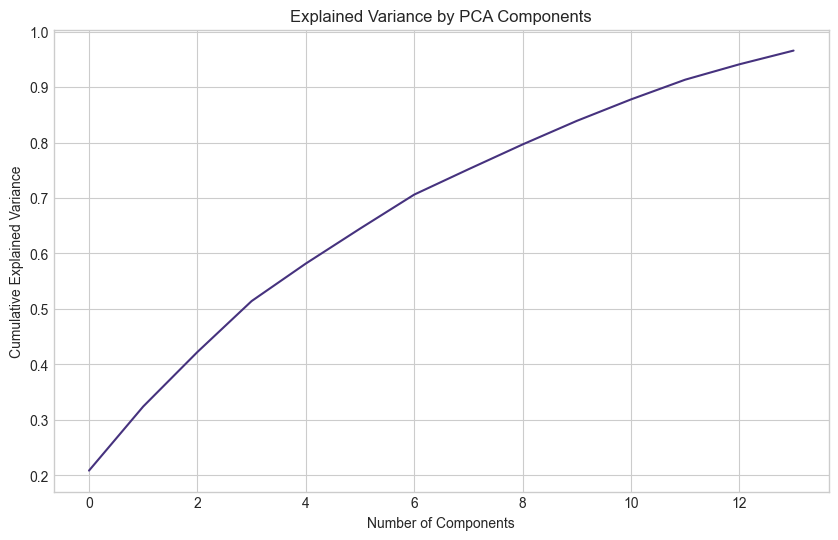

In [32]:
scaler_pca = StandardScaler()
pca = PCA(n_components=0.95)

X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled = scaler_pca.transform(X_test)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train.shape[1]}")
print(f"PCA components: {X_train_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

# Helper Functions

In [33]:
def find_best_threshold(y_true, y_proba, n_thresholds=200):
    """Sweep thresholds and find the one maximizing F1 for Class 1."""
    thresholds = np.linspace(0.05, 0.95, n_thresholds)
    best_f1, best_t = -1, 0.5
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_t = t
    return round(best_t, 4), round(best_f1, 4)

# Store results for comparison
all_results = {}

# Model Implementations

Each model section:
1. Defines model + hyperparameter grid
2. Runs `RandomizedSearchCV` with `scoring=['f1', 'precision', 'recall']`, `refit='f1'`, `cv=cv_strategy`
3. Finds optimal decision threshold
4. Evaluates on test set with: Accuracy, Classification Report, Confusion Matrix

## MLP (Multi-Layer Perceptron) — With PCA

MLP benefits from PCA (reduces noise, speeds up training). Uses scaled+PCA data.

In [ ]:
param_distributions_mlp = {
    'hidden_layer_sizes': [(64, 32), (32, 16), (64, 32, 16)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': uniform(0.0001, 0.01),
    'learning_rate_init': [0.001, 0.005, 0.01],
    'max_iter': [200, 300, 500],
    'batch_size': [32, 64, 128],
}

mlp_search = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42, early_stopping=True),
    param_distributions=param_distributions_mlp,
    n_iter=20,
    cv=cv_strategy,
    scoring=['f1', 'precision', 'recall'],
    refit='f1',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
mlp_search.fit(X_train_pca, y_train)
mlp_time = time.time() - start

best_mlp = mlp_search.best_estimator_
print(f"\nBest parameters: {mlp_search.best_params_}")
print(f"Best CV F1: {mlp_search.best_score_:.4f}")
print(f"Training time: {mlp_time:.1f}s")

In [ ]:
# MLP Evaluation
y_test_proba_mlp = best_mlp.predict_proba(X_test_pca)[:, 1]
best_t_mlp, best_f1_mlp = find_best_threshold(y_test, y_test_proba_mlp)

y_test_pred_mlp = (y_test_proba_mlp >= best_t_mlp).astype(int)

print(f"Best Threshold: {best_t_mlp}")
print(f"Best F1: {best_f1_mlp}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_mlp):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_mlp))

cm_mlp = confusion_matrix(y_test, y_test_pred_mlp)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_mlp).plot(cmap='Blues')
plt.title('MLP — Confusion Matrix (With PCA)')
plt.show()

all_results['MLP (PCA)'] = {
    'f1': best_f1_mlp,
    'accuracy': accuracy_score(y_test, y_test_pred_mlp),
    'threshold': best_t_mlp,
    'precision': precision_score(y_test, y_test_pred_mlp),
    'recall': recall_score(y_test, y_test_pred_mlp),
    'roc_auc': roc_auc_score(y_test, y_test_proba_mlp),
    'time': mlp_time,
    'pca': True
}

In [ ]:
# MLP Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_mlp, X=X_train_pca, y=y_train,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training F1')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation F1')
plt.fill_between(train_sizes,
    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
    np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('MLP Learning Curve (With PCA)')
plt.legend()
plt.grid(True)
plt.show()

## Random Forest — Without PCA

Tree-based models don't need feature scaling or PCA. Trains on raw features.

In [34]:
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_grid_rf = {
    'n_estimators': [200, 500, 800],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=15,
    scoring=['f1', 'precision', 'recall'],
    refit='f1',
    cv=cv_strategy,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_search.fit(X_train, y_train)
rf_time = time.time() - start

best_rf = rf_search.best_estimator_
print(f"\nBest Parameters: {rf_search.best_params_}")
print(f"Best CV F1: {rf_search.best_score_:.4f}")
print(f"Training time: {rf_time:.1f}s")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best CV F1: 0.7825
Training time: 182.2s


Best Threshold: 0.7284
Best F1: 0.8097

Accuracy: 0.9718

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       1.00      0.68      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230



<Figure size 600x500 with 0 Axes>

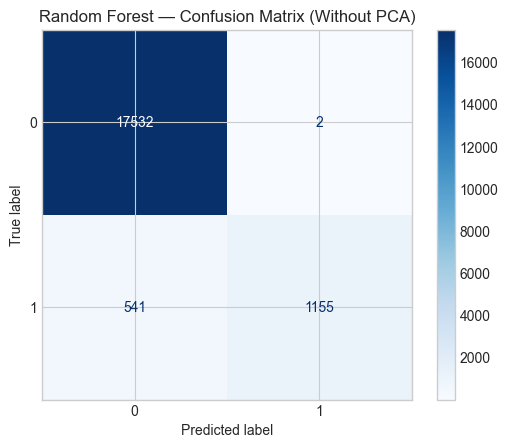


Top 15 Feature Importances:
                      Feature  Importance
6   glucose_hba1c_interaction    0.223445
4                 HbA1c_level    0.209995
9     glucose_bmi_interaction    0.119400
5         blood_glucose_level    0.115056
8         age_bmi_interaction    0.112501
0                         age    0.069886
3                         bmi    0.043741
21          age_groups_Senior    0.022584
7           cardio_risk_index    0.016737
11             high_risk_flag    0.014769
1                hypertension    0.007547
12                gender_Male    0.007008
18         bmi_category_Obese    0.006628
14   smoking_history_baseline    0.005998
19           age_groups_Adult    0.005766


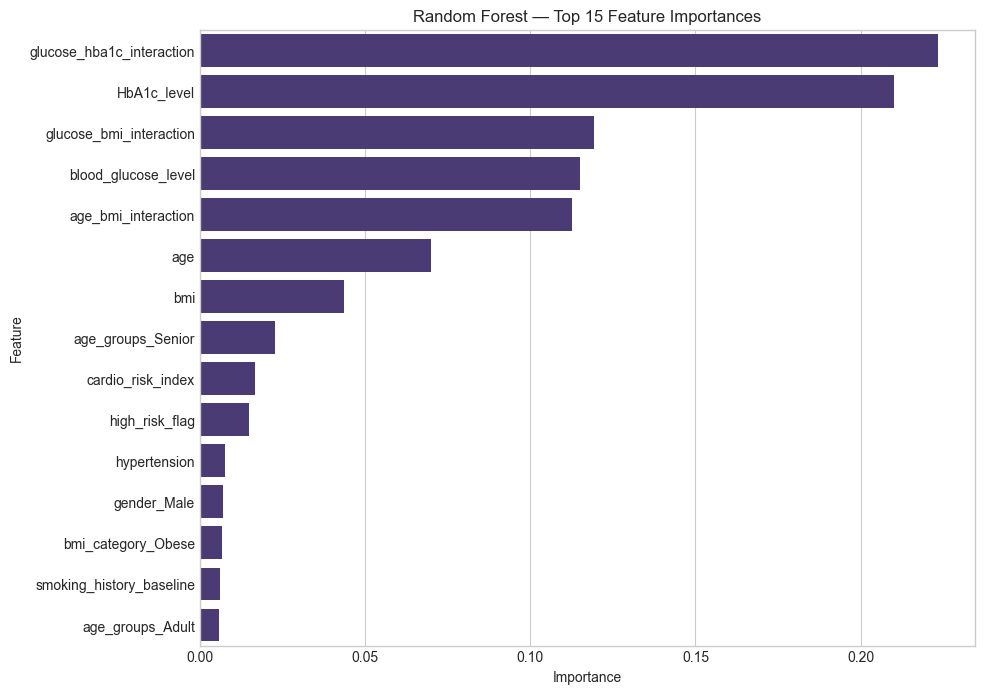

In [35]:
# Random Forest Evaluation
y_test_probs_rf = best_rf.predict_proba(X_test)[:, 1]
best_t_rf, best_f1_rf = find_best_threshold(y_test, y_test_probs_rf)

y_test_pred_rf = (y_test_probs_rf >= best_t_rf).astype(int)

print(f"Best Threshold: {best_t_rf}")
print(f"Best F1: {best_f1_rf}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix (Without PCA)')
plt.show()

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Feature Importances:")
print(feature_importance_rf.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_rf.head(15), x='Importance', y='Feature')
plt.title('Random Forest — Top 15 Feature Importances')
plt.show()

all_results['Random Forest'] = {
    'f1': best_f1_rf,
    'accuracy': accuracy_score(y_test, y_test_pred_rf),
    'threshold': best_t_rf,
    'precision': precision_score(y_test, y_test_pred_rf),
    'recall': recall_score(y_test, y_test_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_test_probs_rf),
    'time': rf_time,
    'pca': False
}

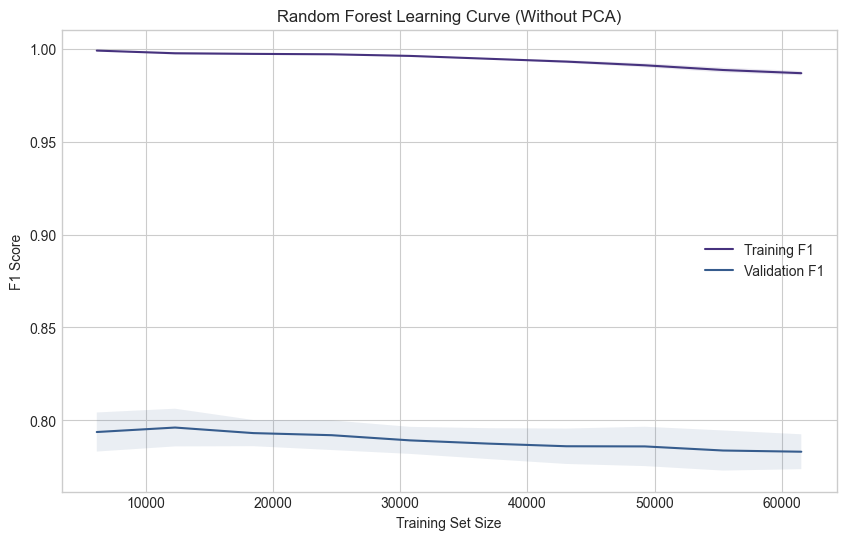

In [36]:
# Random Forest Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_rf, X=X_train, y=y_train,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training F1')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation F1')
plt.fill_between(train_sizes,
    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
    np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Random Forest Learning Curve (Without PCA)')
plt.legend()
plt.grid(True)
plt.show()

## Gradient Boosting — Without PCA

Tree-based ensemble. Trains on raw features.

In [37]:
gb_model = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_leaf': [1, 3, 5]
}

gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_grid_gb,
    n_iter=15,
    scoring=['f1', 'precision', 'recall'],
    refit='f1',
    cv=cv_strategy,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
gb_search.fit(X_train, y_train)
gb_time = time.time() - start

best_gb = gb_search.best_estimator_
print(f"\nBest Parameters: {gb_search.best_params_}")
print(f"Best CV F1: {gb_search.best_score_:.4f}")
print(f"Training time: {gb_time:.1f}s")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_leaf': 3, 'max_depth': 3, 'learning_rate': 0.1}
Best CV F1: 0.8047
Training time: 328.9s


Best Threshold: 0.4706
Best F1: 0.8145

Accuracy: 0.9718

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.97      0.70      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.97      0.85      0.90     19230
weighted avg       0.97      0.97      0.97     19230



<Figure size 600x500 with 0 Axes>

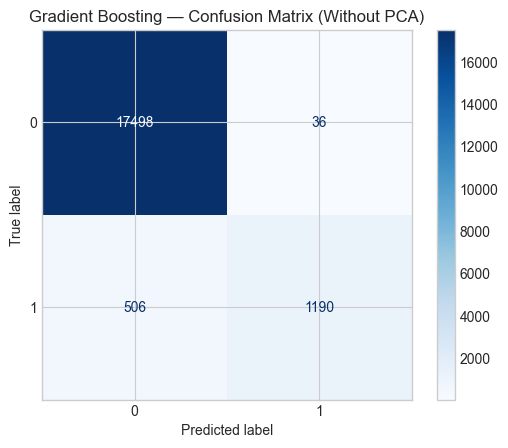


Top 15 Feature Importances:
                      Feature  Importance
4                 HbA1c_level    0.598060
5         blood_glucose_level    0.291774
8         age_bmi_interaction    0.051837
6   glucose_hba1c_interaction    0.037740
7           cardio_risk_index    0.006863
9     glucose_bmi_interaction    0.006833
3                         bmi    0.003359
0                         age    0.001105
2               heart_disease    0.000594
14   smoking_history_baseline    0.000460
12                gender_Male    0.000449
15     smoking_history_former    0.000394
1                hypertension    0.000311
21          age_groups_Senior    0.000055
10             bmi_is_default    0.000049


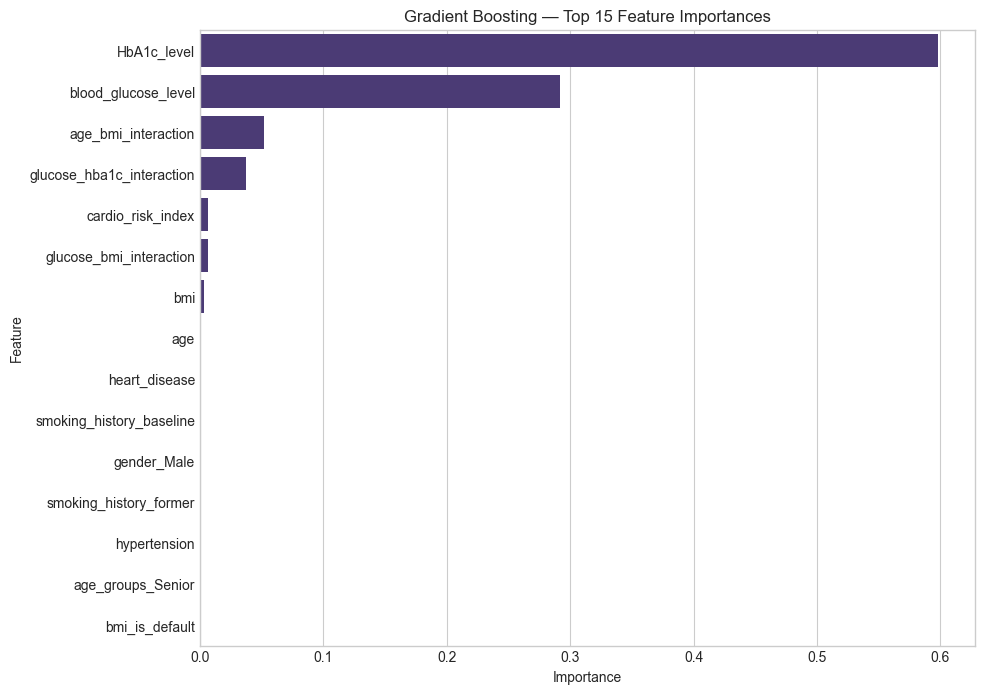

In [38]:
# Gradient Boosting Evaluation
y_test_probs_gb = best_gb.predict_proba(X_test)[:, 1]
best_t_gb, best_f1_gb = find_best_threshold(y_test, y_test_probs_gb)

y_test_pred_gb = (y_test_probs_gb >= best_t_gb).astype(int)

print(f"Best Threshold: {best_t_gb}")
print(f"Best F1: {best_f1_gb}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_gb))

cm_gb = confusion_matrix(y_test, y_test_pred_gb)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_gb).plot(cmap='Blues')
plt.title('Gradient Boosting — Confusion Matrix (Without PCA)')
plt.show()

# Feature Importance
feature_importance_gb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Feature Importances:")
print(feature_importance_gb.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_gb.head(15), x='Importance', y='Feature')
plt.title('Gradient Boosting — Top 15 Feature Importances')
plt.show()

all_results['Gradient Boosting'] = {
    'f1': best_f1_gb,
    'accuracy': accuracy_score(y_test, y_test_pred_gb),
    'threshold': best_t_gb,
    'precision': precision_score(y_test, y_test_pred_gb),
    'recall': recall_score(y_test, y_test_pred_gb),
    'roc_auc': roc_auc_score(y_test, y_test_probs_gb),
    'time': gb_time,
    'pca': False
}

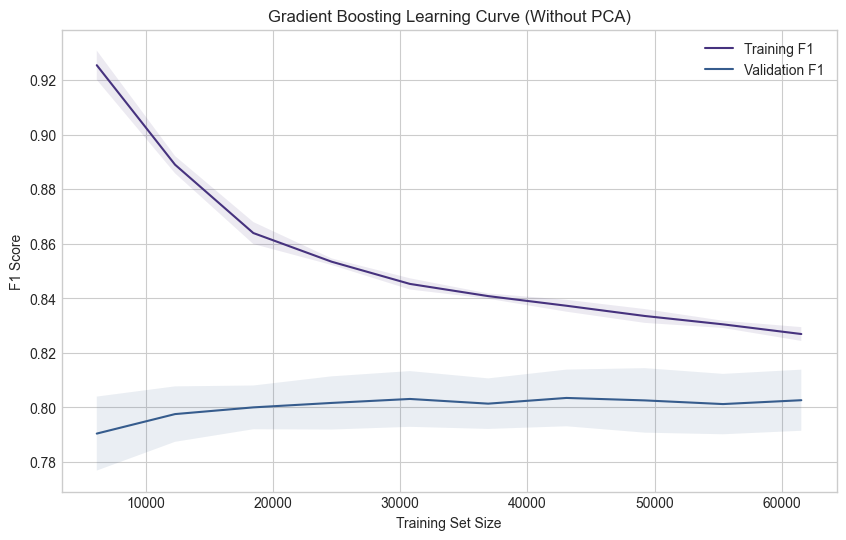

In [39]:
# Gradient Boosting Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_gb, X=X_train, y=y_train,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training F1')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation F1')
plt.fill_between(train_sizes,
    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
    np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Gradient Boosting Learning Curve (Without PCA)')
plt.legend()
plt.grid(True)
plt.show()

## Logistic Regression — Placeholder

> **TODO**: To be implemented by team member.

Notes:
- Linear model. Should use scaled data (X_train_scaled / X_test_scaled) or PCA data.
Handle imbalance with `class_weight='balanced'`.
- Use `cv_strategy` for cross-validation
- Use `find_best_threshold()` for optimal threshold
- Store results in `all_results['Logistic Regression']` dict with keys: f1, accuracy, threshold, precision, recall, roc_auc, time, pca

In [40]:
# TODO: Implement Logistic Regression
# Follow the same pattern as Random Forest / Gradient Boosting above
pass

## Naive Bayes — Placeholder

> **TODO**: To be implemented by team member.

Notes:
- Works well with scaled features. Use `GaussianNB()` on scaled data.
No built-in class_weight — consider adjusting threshold or using SMOTE if needed.
- Use `cv_strategy` for cross-validation
- Use `find_best_threshold()` for optimal threshold
- Store results in `all_results['Naive Bayes']` dict with keys: f1, accuracy, threshold, precision, recall, roc_auc, time, pca

In [ ]:
# TODO: Implement Naive Bayes
# Follow the same pattern as Random Forest / Gradient Boosting above
pass

## SVM (Linear and Kernel) — Placeholder

> **TODO**: To be implemented by team member.

Notes:
- Requires scaled data. Use `LinearSVC` for linear and `SVC(kernel='rbf')` for Gaussian.
**Task requirement**: Use Particle Swarm Optimization (PSO) AND Grid Search for SVM Gaussian Kernel hyperparameters (Gamma, C).
Handle imbalance with `class_weight='balanced'`.
- Use `cv_strategy` for cross-validation
- Use `find_best_threshold()` for optimal threshold
- Store results in `all_results['SVM (Linear and Kernel)']` dict with keys: f1, accuracy, threshold, precision, recall, roc_auc, time, pca

In [ ]:
# TODO: Implement SVM (Linear and Kernel)
# Follow the same pattern as Random Forest / Gradient Boosting above
pass

# Model Comparison

Summary of all trained models, sorted by F1 score.

In [ ]:
# Build comparison table
rows = []
for name, data in all_results.items():
    rows.append({
        'Model': name,
        'F1': f"{data['f1']:.4f}",
        'Precision': f"{data['precision']:.4f}",
        'Recall': f"{data['recall']:.4f}",
        'Accuracy': f"{data['accuracy']:.4f}",
        'ROC AUC': f"{data['roc_auc']:.4f}",
        'Threshold': f"{data['threshold']:.4f}",
        'PCA': 'Yes' if data['pca'] else 'No',
        'Time': f"{data['time']:.1f}s"
    })

results_df = pd.DataFrame(rows).set_index('Model').sort_values('F1', ascending=False)
print("=" * 80)
print("MODEL COMPARISON — Sorted by F1 Score")
print("=" * 80)
print(results_df.to_string())

best_model = results_df.index[0]
print(f"\n🏆 Best Model: {best_model} (F1={results_df.loc[best_model, 'F1']})")

In [ ]:
# Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))
sorted_results = results_df.sort_values('F1', ascending=True)
f1_values = sorted_results['F1'].astype(float)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(sorted_results)))
bars = ax.barh(sorted_results.index, f1_values, color=colors, edgecolor='black')
for bar, val in zip(bars, f1_values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=9)
ax.set_xlabel('F1 Score (Class 1)', fontsize=12)
ax.set_title('Model Comparison — F1 Score (Threshold-Tuned)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# PCA vs Non-PCA Comparison

Compare models run with PCA against those without PCA.

In [ ]:
# PCA vs Non-PCA comparison
pca_rows = []
for name, data in all_results.items():
    pca_rows.append({
        'Model': name,
        'PCA': 'With PCA' if data['pca'] else 'Without PCA',
        'F1': data['f1'],
        'Accuracy': data['accuracy'],
        'ROC AUC': data['roc_auc']
    })

pca_df = pd.DataFrame(pca_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, metric in enumerate(['F1', 'Accuracy', 'ROC AUC']):
    ax = axes[i]
    for pca_status in ['With PCA', 'Without PCA']:
        subset = pca_df[pca_df['PCA'] == pca_status]
        if not subset.empty:
            ax.barh(subset['Model'] + f' ({pca_status})', subset[metric],
                    label=pca_status, alpha=0.8)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} — PCA vs Non-PCA')
    ax.legend()
plt.tight_layout()
plt.suptitle('PCA vs Non-PCA Model Performance', fontsize=14, fontweight='bold', y=1.02)
plt.show()